In [3]:
from google.colab import files
files = files.upload()

Saving all_emission.csv to all_emission.csv


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("all_emission.csv")

In [5]:
df.head()

,business_id,business_type,date,source_category,activity,amount,unit,emission_factor,emissions_kgCO2e,scope
0,B0001,Bakery,2024-01,electricity,electricity_consumption,2022.0,kWh,0.508,1027.176,Scope 2
1,B0001,Bakery,2024-01,electricity,electricity_consumption,264.0,kWh,0.750,198.000,Scope 2
2,B0001,Bakery,2024-02,electricity,electricity_consumption,2152.0,kWh,0.508,1093.216,Scope 2
3,B0001,Bakery,2024-02,electricity,electricity_consumption,544.0,kWh,0.750,408.000,Scope 2
4,B0001,Bakery,2024-03,electricity,electricity_consumption,2128.0,kWh,0.508,1081.024,Scope 2


In [7]:
df["business_type"].unique()

array(['Bakery', 'Supermarket', 'SmallShop', 'Restaurant', 'Pharmacy',
       'FuelStation'], dtype=object)

In [9]:
#checking for missing values
df.isna().sum()

,0
business_id,0
business_type,0
date,0
source_category,0
activity,0
amount,0
unit,0
emission_factor,0
emissions_kgCO2e,0
scope,0


In [11]:
#statistic summary of our data
df.describe()

,amount,emission_factor,emissions_kgCO2e
count,1880.00000,1880.000000,1880.000000
mean,1783.04766,0.605196,972.011207
std,2401.76181,0.393676,1227.009625
min,10.37000,-0.400000,-39.468000
25%,257.75000,0.508000,147.750000
50%,820.00000,0.508000,500.625000
75%,2109.50000,0.750000,1217.422000
max,11958.00000,3.010000,6074.664000


## Exploratory Data Analysis(EDA)

In [12]:
df.columns

Index(['business_id', 'business_type', 'date', 'source_category', 'activity',
       'amount', 'unit', 'emission_factor', 'emissions_kgCO2e', 'scope'],
      dtype='object')

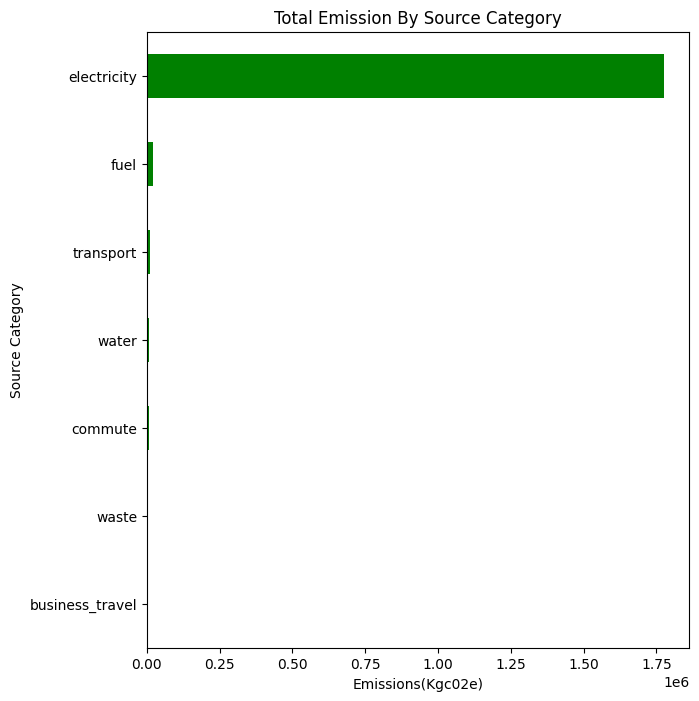

In [16]:
# total emission by source category
df.groupby("source_category")["emissions_kgCO2e"].sum().sort_values(ascending=True).plot(kind="barh", figsize=(7,8), color = "g")
plt.xlabel("Emissions(Kgc02e)")
plt.ylabel("Source Category")
plt.title("Total Emission By Source Category")
plt.show()

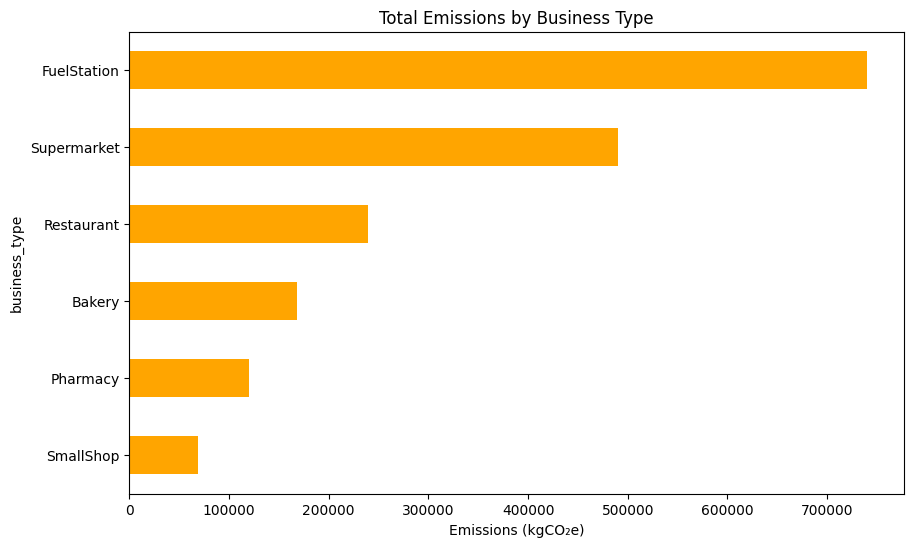

In [17]:
# total emmission by business type
df.groupby("business_type")["emissions_kgCO2e"].sum().sort_values().plot(
    kind="barh", figsize=(10,6), color="orange"
)
plt.title("Total Emissions by Business Type")
plt.xlabel("Emissions (kgCO₂e)")
plt.show()


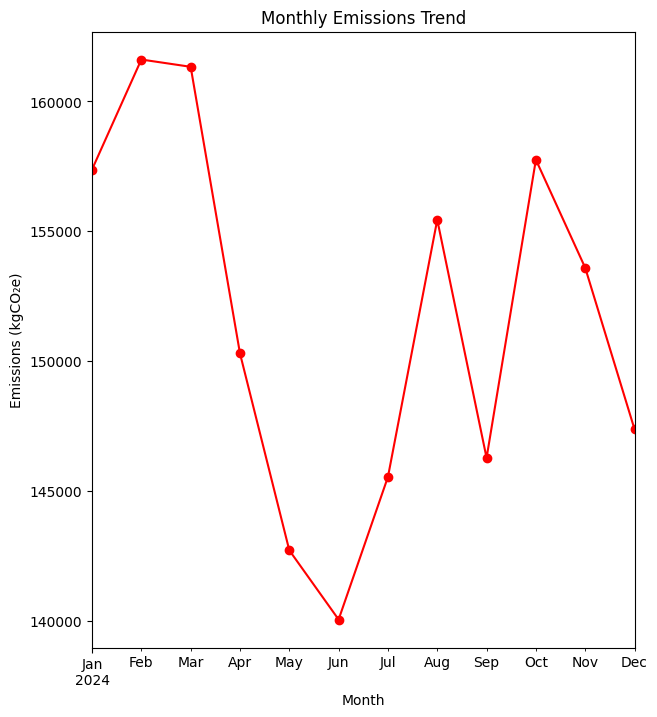

In [21]:
# monthly trend
df["date"] = pd.to_datetime(df["date"], errors = "coerce")
df.groupby(df["date"].dt.to_period("M"))["emissions_kgCO2e"].sum().plot(kind="line", figsize=(7,8), marker="o", color = "r")
plt.title("Monthly Emissions Trend")
plt.ylabel("Emissions (kgCO₂e)")
plt.xlabel("Month")
plt.show()


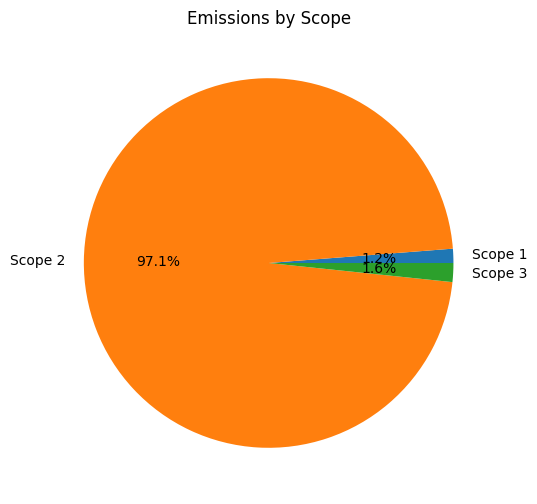

In [23]:
# total emission by scope(scope summary)
df.groupby("scope")["emissions_kgCO2e"].sum().plot(
    kind="pie", autopct="%.1f%%", figsize=(6,6)
)
plt.title("Emissions by Scope")
plt.ylabel("")
plt.show()


scope 2 takes 97 percent of total emission

The highest contributor is electricity, accounting for 1,774,622.45 kgCO₂e (≈97% of total emissions).


# Emissions by Scope
-	Scope 2 (Purchased Electricity): 1,774,622.00 kgCO₂e
-	Scope 3 (Value Chain – Travel, Waste, Water, Transport, Commute): 30,139.34 kgCO₂e
-	Scope 1 (Direct Fuel Use): 22,619.28 kgCO₂e
